In [48]:
import os
import copy
import math
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
from typing import List, Tuple, Dict, Optional
from tqdm.notebook import tqdm
from sklearn.neighbors import BallTree

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.utils import from_networkx
from multiprocessing import Pool, cpu_count

import warnings
warnings.filterwarnings('ignore')

# Global Style & Configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})

# Physics & Constraints
DISTANCE_THRESHOLD_KM = 5.0
MAX_TIME_MINUTES = 45.0
AVERAGE_SPEED_KMH = 30.0
PICKUP_BUFFER_MIN = 5.0

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on device: {DEVICE}")

Executing on device: cuda


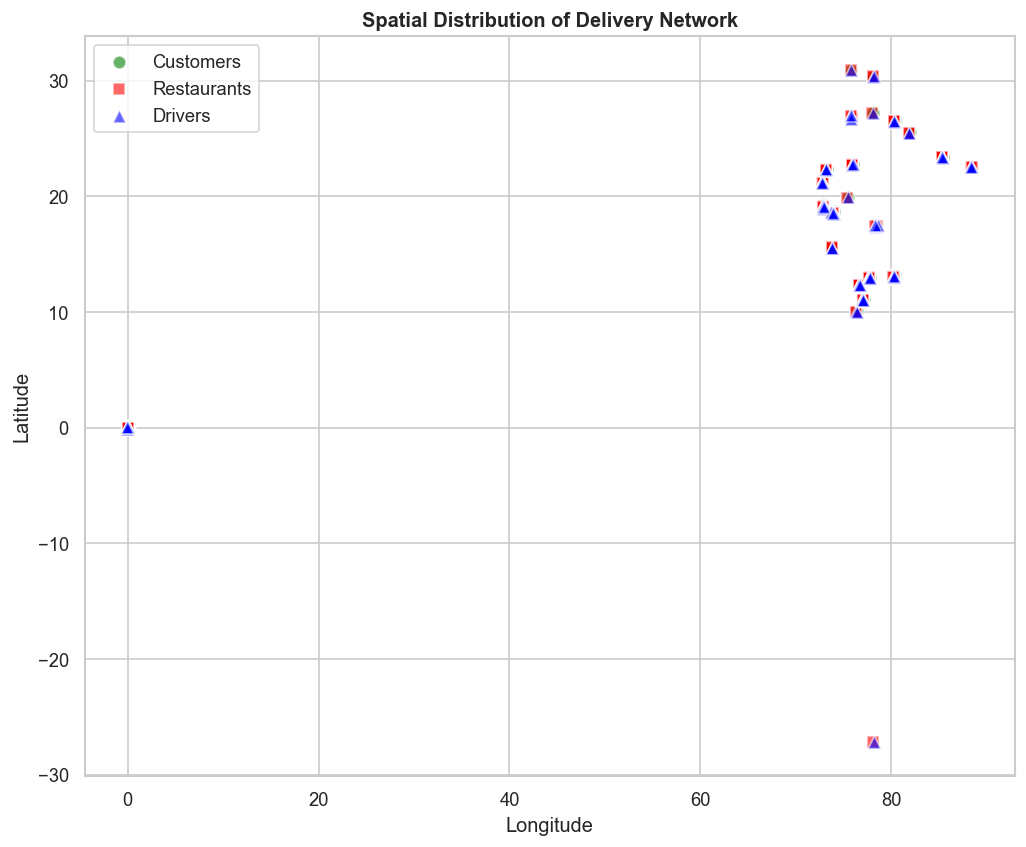

In [49]:
# %% [markdown]
# ## 1. Data Generation & Spatial Analysis
# We generate a synthetic dataset representing the spatial distribution of our tripartite graph nodes.

# %%
def haversine(lat1, lon1, lat2, lon2):
    """Calculates the great-circle distance between two points on the Earth surface."""
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    a = math.sin((lat2 - lat1)/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1)/2)**2
    return R * (2 * math.atan2(math.sqrt(a), math.sqrt(1-a)))

def get_or_create_dataset(filepath='../test/train_with_all_distances.csv', n_rows=200):
    if os.path.exists(filepath):
        return pd.read_csv(filepath).head(n_rows)
    else:
        print("Dataset not found. Generating synthetic spatial dataset...")
        data = []
        for i in range(n_rows):
            base_lat, base_lon = 40.7128, -74.0060 
            rlat = base_lat + np.random.uniform(-0.05, 0.05)
            rlon = base_lon + np.random.uniform(-0.05, 0.05)
            clat = rlat + np.random.uniform(-0.04, 0.04)
            clon = rlon + np.random.uniform(-0.04, 0.04)
            dlat = rlat + np.random.uniform(-0.04, 0.04)
            dlon = rlon + np.random.uniform(-0.04, 0.04)
            
            data.append({
                'ID': f"0x{i}",
                'Delivery_person_ID': f"DP_{i%50}", 
                'Restaurant_latitude': rlat,
                'Restaurant_longitude': rlon,
                'Delivery_location_latitude': clat,
                'Delivery_location_longitude': clon,
                'Driver_latitude': dlat,
                'Driver_longitude': dlon
            })
        return pd.DataFrame(data)

def visualize_spatial_distribution(df):
    """Plots the spatial layout of Customers, Restaurants, and Drivers."""
    plt.figure(figsize=(10, 8))
    plt.scatter(df['Delivery_location_longitude'], df['Delivery_location_latitude'], 
                c='green', label='Customers', alpha=0.6, edgecolors='w', s=60)
    plt.scatter(df['Restaurant_longitude'], df['Restaurant_latitude'], 
                c='red', label='Restaurants', marker='s', alpha=0.6, edgecolors='w', s=60)
    plt.scatter(df['Driver_longitude'], df['Driver_latitude'], 
                c='blue', label='Drivers', marker='^', alpha=0.6, edgecolors='w', s=60)
    
    plt.title("Spatial Distribution of Delivery Network", weight='bold')
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.show()

# Generate and visualize
df_spatial = get_or_create_dataset()
visualize_spatial_distribution(df_spatial)

In [50]:
# %% [markdown]
# ## 2. Spatial Matching Environment (MDP Formulation)
# Encapsulates the graph logic, tracking state transitions, valid edge generation, and computing offline optimal bounds using NetworkX bipartite matching.

# %%
def get_pyg_data(env):
    if not hasattr(env, 'pyg_edge_index'):
        for node in env.G.nodes():
            env.G.nodes[node].setdefault('lat', 0.0)
            env.G.nodes[node].setdefault('lon', 0.0)
            env.G.nodes[node].setdefault('partition', 'V_i')
            env.G.nodes[node].setdefault('target_rest', None)
            
        for u, v, data in env.G.edges(data=True):
            data.setdefault('dist_rd', 0.0)
            data.setdefault('dist_cd', 0.0)
            data.setdefault('dist_cr', 0.0)
        
        pyg_graph = from_networkx(env.G)
        env.pyg_edge_index = pyg_graph.edge_index
    
    node_feats = []
    for n, d in env.G.nodes(data=True):
        p = d.get('partition')
        dynamic_state = 0.0
        if p == 'V_i':
            driver_idx = env.driver_to_idx[n]
            dynamic_state = float(env.I_state[driver_idx])
            
        feat = [
            d.get('lat', 0.0), 
            d.get('lon', 0.0),
            1.0 if p == 'V_i' else 0.0, 
            1.0 if p == 'V_l' else 0.0, 
            1.0 if p == 'V_r' else 0.0, 
            dynamic_state               
        ]
        node_feats.append(feat)
    
    x = torch.tensor(node_feats, dtype=torch.float)
    return x, env.pyg_edge_index

class SpatialMatchingEnv:
    def __init__(self, df):
        self.df = df
        self.G = self._build_graph()
        self.drivers = [n for n, d in self.G.nodes(data=True) if d.get('partition') == 'V_i']
        self.driver_to_idx = {d: i for i, d in enumerate(self.drivers)}
        self.idx_to_driver = {i: d for i, d in enumerate(self.drivers)}
        self.n_I = len(self.drivers)
        self.node_to_idx = {n: i for i, n in enumerate(self.G.nodes())}
        self.adj_matrix = np.zeros((len(self.G.nodes()), self.n_I), dtype=np.float32)
        
        for node in self.G.nodes():
            if node in self.node_to_idx:
                for d in self.G.neighbors(node):
                    if d in self.driver_to_idx:
                        self.adj_matrix[self.node_to_idx[node], self.driver_to_idx[d]] = 1.0
                        
        self.full_adj_matrix = nx.to_numpy_array(self.G)
        self.full_adj_matrix = torch.FloatTensor(self.full_adj_matrix)

    def reset(self, arrival_order):
        self.arrival_order = arrival_order
        self.I_state = np.zeros(self.n_I, dtype=np.int32)
        self.driver_assignments = {i: {'L': None, 'R': None} for i in range(self.n_I)}
        self.matched_triples = []
        self.current_step = 0
        self.done = len(arrival_order) == 0
        return self._get_state()

    def _build_graph(self):
        G = nx.Graph()
        for _, row in self.df.iterrows():
            cust_node = f"Cust_{row['ID']}"
            rest_node = f"Rest_{round(row['Restaurant_latitude'], 4)}_{round(row['Restaurant_longitude'], 4)}"
            driver_node = f"Driver_{row['Delivery_person_ID']}"
            
            G.add_node(cust_node, partition='V_l', target_rest=rest_node,
                       lat=row['Delivery_location_latitude'], lon=row['Delivery_location_longitude'])
            G.add_node(rest_node, partition='V_r', 
                       lat=row['Restaurant_latitude'], lon=row['Restaurant_longitude'])
            G.add_node(driver_node, partition='V_i', 
                       lat=row['Driver_latitude'], lon=row['Driver_longitude'])

        driver_nodes = [n for n, d in G.nodes(data=True) if d.get('partition') == 'V_i']
        rest_nodes = [n for n, d in G.nodes(data=True) if d.get('partition') == 'V_r']
        
        if not driver_nodes or not rest_nodes: return G

        # Vectorized distance thresholding using BallTree
        d_coords = np.radians([[G.nodes[n]['lat'], G.nodes[n]['lon']] for n in driver_nodes])
        r_coords = np.radians([[G.nodes[n]['lat'], G.nodes[n]['lon']] for n in rest_nodes])
        tree = BallTree(d_coords, metric='haversine')
        indices_within_radius = tree.query_radius(r_coords, r=DISTANCE_THRESHOLD_KM / 6371.0)

        # Driver ↔ Restaurant edges
        for r_idx, d_indices in enumerate(indices_within_radius):
            rest_node = rest_nodes[r_idx]
            for d_idx in d_indices:
                driver_node = driver_nodes[d_idx]

                dist_rd = haversine(
                    G.nodes[driver_node]['lat'], G.nodes[driver_node]['lon'],
                    G.nodes[rest_node]['lat'], G.nodes[rest_node]['lon']
                )

                G.add_edge(rest_node, driver_node, dist_rd=dist_rd)

        # Customer ↔ Driver edges
        for cust_node in [n for n, d in G.nodes(data=True) if d.get('partition') == 'V_l']:
            target_rest = G.nodes[cust_node]['target_rest']

            if G.has_node(target_rest):
                for driver_node in G.neighbors(target_rest):
                
                    dist_cd = haversine(
                        G.nodes[cust_node]['lat'], G.nodes[cust_node]['lon'],
                        G.nodes[driver_node]['lat'], G.nodes[driver_node]['lon']
                    )

                    dist_cr = haversine(
                        G.nodes[cust_node]['lat'], G.nodes[cust_node]['lon'],
                        G.nodes[target_rest]['lat'], G.nodes[target_rest]['lon']
                    )

                    G.add_edge(cust_node, driver_node,
                               dist_cd=dist_cd,
                               dist_cr=dist_cr)
        return G

    def _get_state(self):
        return {'I_state': self.I_state.copy(), 'current_step': self.current_step}
    
    def _compute_total_time(self, c_node, d_node, r_node):
        d_rest = self.G[r_node][d_node]['dist_rd']
        d_c_r = self.G[c_node][d_node]['dist_cr']

        total_time = ((d_rest / AVERAGE_SPEED_KMH) * 60) \
                   + PICKUP_BUFFER_MIN \
                   + ((d_c_r / AVERAGE_SPEED_KMH) * 60)
        return total_time, d_rest, d_c_r


    def _is_feasible(self, c_node, d_node, r_node):
        if self.G.nodes[c_node].get('target_rest') != r_node:
            return False, None
        if not self.G.has_edge(c_node, d_node) or not self.G.has_edge(r_node, d_node):
            return False, None

        total_time, d_rest, d_c_r = self._compute_total_time(c_node, d_node, r_node)
        return total_time <= MAX_TIME_MINUTES, (total_time, d_rest, d_c_r)

    def step(self, action_idx: Optional[int]):
        if self.done:
            return self._get_state(), 0.0, True

        node_type, node_id = self.arrival_order[self.current_step]
        reward = 0.0
        total_time = None

        if action_idx is not None and action_idx < self.n_I:
            driver_node = self.idx_to_driver[action_idx]

            if node_type == 'L':
                r_node = self.driver_assignments[action_idx]['R']

                if r_node:
                    feasible, info = self._is_feasible(node_id, driver_node, r_node)

                    if feasible:
                        total_time, _, _ = info
                        time_score = 1 - (total_time / MAX_TIME_MINUTES)
                        reward = 0.7 * time_score + 0.3

                        self.matched_triples.append((node_id, driver_node, r_node))
                        self.I_state[action_idx] = 0
                        self.driver_assignments[action_idx] = {'L': None, 'R': None, 'partial': None}

                    else:
                        reward = -0.1
                        self.I_state[action_idx] = 1
                        self.driver_assignments[action_idx]['L'] = node_id

                else:
                    reward = 0.05
                    self.I_state[action_idx] = 1
                    self.driver_assignments[action_idx]['L'] = node_id

                    # store partial pickup distance
                    if self.G.has_edge(node_id, driver_node):
                        _, d_rest, _ = self._compute_total_time(node_id, driver_node, 
                            self.G.nodes[node_id]['target_rest'])
                        self.driver_assignments[action_idx]['partial'] = d_rest

            elif node_type == 'R':
                c_node = self.driver_assignments[action_idx]['L']

                if c_node:
                    feasible, info = self._is_feasible(c_node, driver_node, node_id)

                    if feasible:
                        total_time, _, _ = info
                        time_score = 1 - (total_time / MAX_TIME_MINUTES)
                        reward = 0.7 * time_score + 0.3

                        self.matched_triples.append((c_node, driver_node, node_id))
                        self.I_state[action_idx] = 0
                        self.driver_assignments[action_idx] = {'L': None, 'R': None, 'partial': None}

                    else:
                        reward = -0.1
                        self.I_state[action_idx] = 2
                        self.driver_assignments[action_idx]['R'] = node_id

                else:
                    reward = 0.05
                    self.I_state[action_idx] = 2
                    self.driver_assignments[action_idx]['R'] = node_id

        else:
            reward = -0.1

        reward -= 0.01
        self.current_step += 1
        
        if self.current_step >= len(self.arrival_order):
            self.done = True

        return self._get_state(), reward, self.done

    def get_eligible_drivers(self, node_type, node_id) -> List[int]:
        eligible = []
        for i, driver in self.idx_to_driver.items():
            if node_type == 'L' and self.G.has_edge(node_id, driver) and self.I_state[i] in [0, 2]:
                eligible.append(i)
            elif node_type == 'R' and self.G.has_edge(node_id, driver) and self.I_state[i] in [0, 1]:
                eligible.append(i)
        return eligible

    def compute_offline_optimal(self):
        B = nx.Graph()
        for c in [n for n, d in self.G.nodes(data=True) if d.get('partition') == 'V_l']:
            target_r = self.G.nodes[c].get('target_rest')
            if not self.G.has_node(target_r): continue
            shared_drivers = set(self.G.neighbors(c)).intersection(set(self.G.neighbors(target_r)))
            for d in shared_drivers:
                if self._is_feasible(c, d, target_r): B.add_edge(f"Order_{c}_{target_r}", d)
        # Bipartite matching provides the absolute upper bound of matching capacity
        return len(nx.bipartite.maximum_matching(B, top_nodes=[n for n in B.nodes if n.startswith("Order")])) // 2

In [51]:
# %% [markdown]
# ## 3. Operations Research Heuristics
# We define standard benchmark algorithms to compare against our learning agents.

# %%
class BaseAlgorithm:
    def run_episode(self, env):
        while not env.done:
            ntype, nid = env.arrival_order[env.current_step]
            eligible = env.get_eligible_drivers(ntype, nid)
            action = self.select_action(env, ntype, nid, eligible)
            env.step(action if action is not None and action < env.n_I else None)
        return len(env.matched_triples)

class RandomAlgorithm(BaseAlgorithm):
    def select_action(self, env, node_type, node_id, eligible):
        return random.choice(eligible) if eligible else None

class MinDistanceAlgorithm(BaseAlgorithm):
    """Greedily picks closest driver using available distance attributes."""
    def select_action(self, env, node_type, node_id, eligible):
        if not eligible:
            return None

        def get_dist(idx):
            driver = env.idx_to_driver[idx]
            edge_data = env.G.get_edge_data(node_id, driver, default={})

            # Prefer customer-driver distance if exists
            if 'dist_cd' in edge_data:
                return edge_data['dist_cd']
            elif 'dist_rd' in edge_data:
                return edge_data['dist_rd']
            return float('inf')

        return min(eligible, key=get_dist)

class MinDegreeAlgorithm(BaseAlgorithm):
    """Preserves highly connected drivers by assigning the least flexible driver first."""
    def select_action(self, env, node_type, node_id, eligible):
        if not eligible: return None
        return min(eligible, key=lambda idx: env.G.degree(env.idx_to_driver[idx]))
    
class EpsilonRankingAlgorithm(BaseAlgorithm):
    def __init__(self, n_I: int):
        self.ranks = np.random.uniform(0, 1, n_I)
        self.n_I = n_I
    def run_episode(self, env):
        self.ranks = np.random.uniform(0, 1, self.n_I)
        return super().run_episode(env)
    def select_action(self, env, node_type, node_id, eligible):
        if not eligible: return None
        return min(eligible, key=lambda i: self.ranks[i])

In [52]:
# %% [markdown]
# ## 4. Deep Learning Architectures
# Implements MLP, RNNs, Self-Attention, and a Graph Neural Network (GNN) node embedding.

# %%
class UnifiedRLNetwork(nn.Module):
    def __init__(self, n_I, arch='lstm', is_q_net=False, hidden_dim=32): 
        super().__init__()
        self.n_I = n_I
        self.arch = arch
        self.is_q_net = is_q_net
        self.input_dim = 2 + n_I + (3 * n_I) + n_I + 1  
        
        # 1. Base Architectures
        if arch == 'mlp':
            self.core = nn.Sequential(
                nn.Linear(self.input_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), 
                nn.Linear(hidden_dim, hidden_dim), nn.GELU()
            )
        elif arch in ['lstm', 'gru']:
            RNNClass = nn.LSTM if arch == 'lstm' else nn.GRU
            self.core = RNNClass(self.input_dim, hidden_dim, batch_first=True)
            self.core.flatten_parameters()
        elif arch == 'transformer':
            self.input_proj = nn.Linear(self.input_dim, hidden_dim)
            encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=2, dim_feedforward=hidden_dim*2, batch_first=True) 
            self.core = nn.TransformerEncoder(encoder_layer, num_layers=1) 
        elif arch == 'gnn':
            self.node_embedding = nn.Linear(6, 32)
            self.conv1 = SAGEConv(32, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, hidden_dim)
            self.global_proj = nn.Linear(hidden_dim + 1, hidden_dim)
            
        # 2. Heads
        if is_q_net:
            self.q_head = nn.Linear(hidden_dim, n_I + 1)
        else:
            self.actor = nn.Linear(hidden_dim, n_I + 1)
            self.critic = nn.Linear(hidden_dim, 1) # Note: GRPO and DPO will ignore the critic

    def forward(self, x, hidden=None):
        if self.arch == 'mlp':
            out = self.core(x)
        elif self.arch in ['lstm', 'gru']:
            out, hidden = self.core(x, hidden)
            out = out[:, -1:, :]
        elif self.arch == 'transformer':
            x = self.input_proj(x)
            out = self.core(x)
            out = out[:, -1:, :] 
        elif self.arch == 'gnn':
            x_nodes, edge_index, global_feat, batch = x
            h = F.relu(self.node_embedding(x_nodes))
            h = F.relu(self.conv1(h, edge_index))
            h = F.relu(self.conv2(h, edge_index))
            graph_repr = global_mean_pool(h, batch)
            combined = torch.cat([graph_repr, global_feat], dim=-1)
            out = F.gelu(self.global_proj(combined))
            
        if self.is_q_net:
            return self.q_head(out), hidden
        return self.actor(out), self.critic(out), hidden

In [53]:
# %% [markdown]
# ## 5. RL Agents (PPO, A2C, DQN)
# Implementation of modern Policy Gradient and Value-Based methods. PPO includes Generalized Advantage Estimation (GAE).

# %%
class BaseRLAgent(BaseAlgorithm):
    def __init__(self, n_I, arch):
        self.n_I = n_I
        self.device = DEVICE
        self.arch = arch
        self.losses = []
        
    def _get_features(self, env, node_type, node_id):
        if self.arch == 'gnn':
            x_nodes, edge_index = get_pyg_data(env)
            x_nodes = x_nodes.to(self.device)
            edge_index = edge_index.to(self.device)
            
            driver_mask = (x_nodes[:, 2] == 1)
            x_nodes[driver_mask, 5] = torch.tensor(env.I_state, dtype=torch.float, device=self.device)
            
            global_feat = torch.tensor([[env.current_step / len(env.arrival_order)]], dtype=torch.float, device=self.device)
            batch = torch.zeros(x_nodes.size(0), dtype=torch.long, device=self.device)
            
            return (x_nodes, edge_index, global_feat, batch)
        else:
            type_vec = [1, 0] if node_type == 'L' else [0, 1]

            node_idx = env.node_to_idx.get(node_id, None)
            neigh_vec = env.adj_matrix[node_idx] if node_idx is not None else np.zeros(self.n_I)
            time_vec = np.zeros(self.n_I)

            for i, driver in env.idx_to_driver.items():
                if env.G.has_edge(node_id, driver):
                    edge = env.G.get_edge_data(node_id, driver, {})
                    if 'dist_cd' in edge:
                        time_vec[i] = edge['dist_cd'] / DISTANCE_THRESHOLD_KM
                    elif 'dist_rd' in edge:
                        time_vec[i] = edge['dist_rd'] / DISTANCE_THRESHOLD_KM

            degree_vec = time_vec
            state_vec = np.zeros(3 * self.n_I)
            for i, st in enumerate(env.I_state): state_vec[3*i + int(st)] = 1.0
            step_vec = [env.current_step / max(1, len(env.arrival_order))]

            feat = np.concatenate([type_vec, neigh_vec, state_vec, degree_vec, step_vec])

            adj = env.full_adj_matrix.to(self.device)
            return torch.FloatTensor(feat).unsqueeze(0).unsqueeze(0).to(self.device)

    def run_episode(self, env):
        env.reset(env.arrival_order)
        hidden, seq_buffer = None, []
        while not env.done:
            ntype, nid = env.arrival_order[env.current_step]
            eligible = env.get_eligible_drivers(ntype, nid)
            feat = self._get_features(env, ntype, nid)
            
            if self.arch == 'transformer':
                seq_buffer.append(feat)
                feat_input = torch.cat(seq_buffer[-15:], dim=1) # Context window
            else:
                feat_input = feat
                
            action, hidden = self._select_eval_action(feat_input, eligible, hidden)
            env.step(action if action < self.n_I else None)
        return len(env.matched_triples)

class PPOAgent(BaseRLAgent):
    """SOTA Proximal Policy Optimization with Generalized Advantage Estimation (GAE)."""
    def __init__(self, n_I, arch='gru', clip=0.2, gamma=0.99, lam=0.95):
        super().__init__(n_I, arch)
        self.clip = clip
        self.gamma = gamma
        self.lam = lam
        self.net = UnifiedRLNetwork(n_I, arch=arch).to(self.device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=3e-4)
        self.context_window_size = 10 if arch == 'transformer' else None

    def _select_eval_action(self, feat, eligible, hidden):
        logits, _, hidden = self.net(feat, hidden)
        mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
        mask[-1] = 0
        if eligible: mask[eligible] = 0
        probs = torch.softmax(logits.view(-1) + mask, dim=-1)
        return torch.argmax(probs).item(), hidden

    def train_episode(self, env):
        env.reset(env.arrival_order)
        hidden, states, actions, old_log_probs, rewards, values = None, [], [], [], [], []
        seq_buffer = []
        
        if self.arch == 'transformer':
            seq_buffer = deque(maxlen=self.context_window_size)
        else:
            seq_buffer = []

        # 1. Rollout Trajectory
        while not env.done:
            ntype, nid = env.arrival_order[env.current_step]
            eligible = env.get_eligible_drivers(ntype, nid)
            feat = self._get_features(env, ntype, nid)
            
            if self.arch == 'transformer':
                seq_buffer.append(feat)
                feat_input = torch.cat(list(seq_buffer), dim=1)
            else:
                feat_input = feat
            
            logits, val, hidden = self.net(feat_input, hidden)
            mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
            mask[-1] = 0
            if eligible: mask[eligible] = 0
            
            probs = torch.softmax(logits.view(-1) + mask, dim=-1)
            m = Categorical(probs)
            action = m.sample()
            
            _, reward, _ = env.step(action.item() if action.item() < self.n_I else None)
            
            states.append((feat_input, eligible))
            actions.append(action)
            old_log_probs.append(m.log_prob(action).detach())
            rewards.append(reward)
            values.append(val.detach().view(-1))

        if not rewards: return 0

        # 2. Compute GAE and Returns
        values = torch.cat(values).cpu().numpy()
        advantages = np.zeros_like(rewards, dtype=np.float32)
        last_adv = 0
        for t in reversed(range(len(rewards))):
            next_val = values[t+1] if t + 1 < len(rewards) else 0.0
            delta = rewards[t] + self.gamma * next_val - values[t]
            advantages[t] = last_adv = delta + self.gamma * self.lam * last_adv
            
        returns = torch.tensor(advantages + values).to(self.device)
        advantages = torch.tensor(advantages).to(self.device)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # 3. PPO Surrogate Loss Update
        ep_loss = 0
        for _ in range(3): # Epochs
            total_loss = 0
            for i, ((feat_input, eligible), action, old_lp, adv, ret) in enumerate(
                zip(states, actions, old_log_probs, advantages, returns)
            ):
                logits, value, _ = self.net(feat_input, hidden=None)
                
                mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
                mask[-1] = 0
                if eligible: mask[eligible] = 0
                
                probs = torch.softmax(logits.view(-1) + mask, dim=-1)
                dist = Categorical(probs)
                
                new_log_prob = dist.log_prob(action)
                ratio = torch.exp(new_log_prob - old_lp)
                
                surr1 = ratio * adv
                surr2 = torch.clamp(ratio, 1 - self.clip, 1 + self.clip) * adv
                
                actor_loss = -torch.min(surr1, surr2)
                critic_loss = F.mse_loss(value.view(-1), ret.view(-1))
                entropy = dist.entropy()
                
                loss = actor_loss + 0.5 * critic_loss - 0.05 * entropy
                
                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.net.parameters(), 0.5)
                self.optimizer.step()
                
                total_loss += loss.item()
            
            ep_loss = total_loss / len(states) if states else 0
                
        self.losses.append(ep_loss)
        return sum(rewards)
    
class A2CAgent(BaseRLAgent):
    """Advantage Actor-Critic (A2C) baseline model."""
    def __init__(self, n_I, arch='mlp', gamma=0.99):
        super().__init__(n_I, arch)
        self.gamma = gamma
        self.net = UnifiedRLNetwork(n_I, arch=arch).to(self.device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)
        self.context_window = 15 if arch == 'transformer' else None


    def _select_eval_action(self, feat, eligible, hidden):
        logits, _, hidden = self.net(feat, hidden)
        mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
        mask[-1] = 0
        if eligible: mask[eligible] = 0
        probs = torch.softmax(logits.view(-1) + mask, dim=-1)
        return torch.argmax(probs).item(), hidden

    def train_episode(self, env):
        env.reset(env.arrival_order)
        hidden, seq_buffer = None, []
        trajectory = []
        log_probs, values, rewards = [], [], []
        
        if self.arch == 'transformer':
            seq_buffer = deque(maxlen=self.context_window)
        else:
            seq_buffer = []

        while not env.done:
            ntype, nid = env.arrival_order[env.current_step]
            eligible = env.get_eligible_drivers(ntype, nid)
            feat = self._get_features(env, ntype, nid)
            
            if self.arch == 'transformer':
                seq_buffer.append(feat)
                feat_input = torch.cat(list(seq_buffer), dim=1)
            else:
                feat_input = feat

            logits, val, hidden = self.net(feat_input, hidden)
            mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
            mask[-1] = 0
            if eligible: mask[eligible] = 0
            
            probs = torch.softmax(logits.view(-1) + mask, dim=-1)
            m = Categorical(probs)
            action = m.sample()
            
            _, reward, _ = env.step(action.item() if action.item() < self.n_I else None)
            
            if isinstance(feat_input, tuple):
                detached_feat = tuple(f.detach() if torch.is_tensor(f) else f for f in feat_input)
            else:
                detached_feat = feat_input.detach()
    
            trajectory.append({
                'feat': detached_feat,
                'eligible': eligible,
                'action': action.detach(),
                'log_prob': m.log_prob(action).detach(),
                'reward': reward,
                'value': val.detach().view(-1)
            })
    
        if not trajectory: return 0

        # Compute discounted returns
        rewards = [t['reward'] for t in trajectory]
        values = [t['value'] for t in trajectory]
        
        returns = []
        R = 0
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)
            
        returns = torch.tensor(returns).to(self.device)
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # Compute A2C Loss
        total_policy_loss = 0
        total_value_loss = 0
        
        for step_data, R in zip(trajectory, returns):
            feat = step_data['feat']
            action = step_data['action']
            eligible = step_data['eligible']
            
            logits, value, _ = self.net(feat, hidden=None)
            
            mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
            mask[-1] = 0
            if eligible: mask[eligible] = 0
            
            log_prob = Categorical(torch.softmax(logits.view(-1) + mask, dim=-1)).log_prob(action)
            
            advantage = R - value.item()
            policy_loss = -log_prob * advantage
            value_loss = F.smooth_l1_loss(value, torch.tensor([R]).to(self.device))
            
            self.optimizer.zero_grad()
            loss = policy_loss + value_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.net.parameters(), max_norm=0.5)
            self.optimizer.step()
            
            total_policy_loss += policy_loss.item()
            total_value_loss += value_loss.item()
        
        avg_loss = (total_policy_loss + total_value_loss) / len(trajectory) if trajectory else 0
        self.losses.append(avg_loss)
        return sum(rewards)
    
class GRPOAgent(BaseRLAgent):
    """
    Group Relative Policy Optimization.
    Samples a group of G trajectories, normalizes rewards within the group, 
    and updates policy without a Value Network.
    """
    def __init__(self, n_I, arch='mlp', group_size=4, clip=0.2):
        super().__init__(n_I, arch)
        self.group_size = group_size
        self.clip = clip
        self.net = UnifiedRLNetwork(n_I, arch=arch).to(self.device)
        self.optimizer = optim.Adam(self.net.actor.parameters(), lr=3e-4) # Only optimizing Actor!

    def _select_eval_action(self, feat, eligible, hidden):
        logits, _, hidden = self.net(feat, hidden)
        mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
        mask[-1] = 0
        if eligible: mask[eligible] = 0
        return torch.argmax(torch.softmax(logits.view(-1) + mask, dim=-1)).item(), hidden

    def train_episode(self, env):
        # We need to run G rollouts on the SAME arrival order to compare relative performance
        group_trajectories = []
        group_rewards = []
        
        for g in range(self.group_size):
            env.reset(env.arrival_order)
            states, actions, old_log_probs = [], [], []
            hidden, seq_buffer = None, []
            
            while not env.done:
                ntype, nid = env.arrival_order[env.current_step]
                eligible = env.get_eligible_drivers(ntype, nid)
                feat = self._get_features(env, ntype, nid)
                
                if self.arch == 'transformer':
                    seq_buffer.append(feat)
                    feat_input = torch.cat(seq_buffer[-15:], dim=1)
                else:
                    feat_input = feat
                
                logits, _, hidden = self.net(feat_input, hidden) # No critic used
                mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
                mask[-1] = 0
                if eligible: mask[eligible] = 0
                
                m = Categorical(torch.softmax(logits.view(-1) + mask, dim=-1))
                action = m.sample()
                _, _, _ = env.step(action.item() if action.item() < self.n_I else None)
                
                states.append((feat_input, eligible))
                actions.append(action)
                old_log_probs.append(m.log_prob(action).detach())
                
            group_trajectories.append((states, actions, old_log_probs))
            group_rewards.append(len(env.matched_triples))

        if len(group_rewards) < 2: return group_rewards[0] if group_rewards else 0

        # Compute Relative Advantages within the Group
        R_tensor = torch.tensor(group_rewards, dtype=torch.float32, device=self.device)
        advantages = (R_tensor - R_tensor.mean()) / (R_tensor.std() + 1e-8)

        # GRPO Policy Update
        self.optimizer.zero_grad()
        total_ep_loss = 0
        
        for g, (states, actions, old_log_probs) in enumerate(group_trajectories):
            adv = advantages[g]
            hidden = None
            traj_loss = 0
            
            for step_idx, ((feat, elig), a, old_lp) in enumerate(zip(states, actions, old_log_probs)):
                logits, _, hidden = self.net(feat, hidden)
                mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
                mask[-1] = 0
                if elig: mask[elig] = 0
                
                m = Categorical(torch.softmax(logits.view(-1) + mask, dim=-1))
                ratio = torch.exp(m.log_prob(a) - old_lp)
                surr1 = ratio * adv
                surr2 = torch.clamp(ratio, 1 - self.clip, 1 + self.clip) * adv
                
                # GRPO Loss
                step_loss = -torch.min(surr1, surr2) - 0.01 * m.entropy()
                traj_loss += step_loss
                
                if (step_idx + 1) % 32 == 0 or (step_idx + 1) == len(states):
                    (traj_loss / self.group_size).backward()
                    total_ep_loss += traj_loss.item()
                    traj_loss = 0 # Reset graph
                    
                    if hidden is not None:
                        # Detach hidden state if using RNN to prevent backprop through time blowing up
                        if isinstance(hidden, tuple):
                            hidden = tuple(h.detach() for h in hidden)
                        else:
                            hidden = hidden.detach()

        torch.nn.utils.clip_grad_norm_(self.net.actor.parameters(), max_norm=0.5)
        self.optimizer.step()
        
        self.losses.append(total_ep_loss / self.group_size)
        return sum(group_rewards) / self.group_size


class DPOAgent(BaseRLAgent):
    """
    Direct Preference Optimization (adapted for RL).
    Maintains a reference model. Collects pairs of actions, 
    preferring actions that led to a match over those that didn't.
    """
    def __init__(self, n_I, arch='mlp', beta=0.1):
        super().__init__(n_I, arch)
        self.beta = beta
        self.net = UnifiedRLNetwork(n_I, arch=arch).to(self.device)
        self.ref_net = copy.deepcopy(self.net) # Frozen reference model
        self.ref_net.eval()
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-4)
        self.update_freq = 10
        self.ep_count = 0

    def _select_eval_action(self, feat, eligible, hidden):
        logits, _, hidden = self.net(feat, hidden)
        mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
        mask[-1] = 0
        if eligible: mask[eligible] = 0
        return torch.argmax(torch.softmax(logits.view(-1) + mask, dim=-1)).item(), hidden

    def train_episode(self, env):
        env.reset(env.arrival_order)
        hidden, ref_hidden = None, None
        transitions = []
        
        while not env.done:
            ntype, nid = env.arrival_order[env.current_step]
            eligible = env.get_eligible_drivers(ntype, nid)
            feat = self._get_features(env, ntype, nid)
            
            # Policy action
            logits, _, hidden = self.net(feat, hidden)
            mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
            mask[-1] = 0
            if eligible: mask[eligible] = 0
            
            m = Categorical(torch.softmax(logits.view(-1) + mask, dim=-1))
            action = m.sample()
            
            # Step env
            _, reward, _ = env.step(action.item() if action.item() < self.n_I else None)
            
            transitions.append((feat, eligible, action, reward))

        # DPO Update: Construct preferences. We prefer actions that yielded immediate reward (match)
        # over actions that yielded 0. (A simplified step-wise preference mapping).
        winners = [t for t in transitions if t[3] > 0]
        losers = [t for t in transitions if t[3] == 0]
        
        if winners and losers:
            self.optimizer.zero_grad()
            dpo_loss = 0
            
            # Sample pairs
            for _ in range(min(len(winners), 16)):
                w = random.choice(winners)
                l = random.choice(losers)
                
                for t, is_winner in [(w, True), (l, False)]:
                    feat, elig, action, _ = t
                    mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
                    mask[-1] = 0
                    if elig: mask[elig] = 0
                    
                    with torch.no_grad():
                        ref_logits, _, _ = self.ref_net(feat)
                        ref_log_prob = Categorical(torch.softmax(ref_logits.view(-1) + mask, dim=-1)).log_prob(action)
                        
                    logits, _, _ = self.net(feat)
                    pi_log_prob = Categorical(torch.softmax(logits.view(-1) + mask, dim=-1)).log_prob(action)
                    
                    ratio = pi_log_prob - ref_log_prob
                    
                    if is_winner:
                        w_ratio = ratio
                    else:
                        l_ratio = ratio
                
                # Bradley-Terry DPO Loss: -log(sigmoid(beta * (log_pi(w)/log_ref(w) - log_pi(l)/log_ref(l))))
                loss = -F.logsigmoid(self.beta * (w_ratio - l_ratio))
                dpo_loss += loss
                
            dpo_loss.backward()
            self.optimizer.step()
            self.losses.append(dpo_loss.item())

        self.ep_count += 1
        if self.ep_count % self.update_freq == 0:
            self.ref_net.load_state_dict(self.net.state_dict())

        return len(env.matched_triples)
    
class TD3Critic(nn.Module):
    def __init__(self, input_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.q1 = nn.Sequential(
            nn.Linear(input_dim + action_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        self.q2 = nn.Sequential(
            nn.Linear(input_dim + action_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, state, action):
        state = state.view(state.size(0), -1)
        sa = torch.cat([state, action], dim=1)
        return self.q1(sa), self.q2(sa)
    
    def Q1(self, state, action):
        state = state.view(state.size(0), -1)
        sa = torch.cat([state, action], dim=1)
        return self.q1(sa)

class TD3Agent(BaseRLAgent):
    """Twin Delayed DDPG mapped to Discrete Output actions using preference scoring."""
    def __init__(self, n_I, arch='mlp', lr=3e-4, gamma=0.99, tau=0.005, policy_noise=0.2, noise_clip=0.5, policy_freq=2):
        super().__init__(n_I, arch)
        self.gamma = gamma
        self.tau = tau
        self.policy_noise = policy_noise
        self.noise_clip = noise_clip
        self.policy_freq = policy_freq
        self.total_it = 0
        self.action_dim = n_I + 1
        
        # Actor uses Unified Network
        self.actor = UnifiedRLNetwork(n_I, arch=arch).to(self.device)
        self.actor_target = copy.deepcopy(self.actor)
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr)

        self.critic = TD3Critic(self.actor.input_dim, self.action_dim).to(self.device)
        self.critic_target = copy.deepcopy(self.critic)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr)
        self.memory = deque(maxlen=5000)

    def _select_eval_action(self, feat, eligible, hidden):
        # We use the actor out, bounding with tanh to represent preference scores
        continuous_action, _, hidden = self.actor(feat, hidden)
        continuous_action = torch.tanh(continuous_action)
        
        mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
        mask[-1] = 0
        if eligible: mask[eligible] = 0
        
        # Combine continuous scores with valid discrete mask
        masked_scores = continuous_action.view(-1) + mask
        return torch.argmax(masked_scores).item(), hidden

    def train_episode(self, env):
        env.reset(env.arrival_order)
        hidden = None
        ep_reward, ep_loss = 0, 0
        
        while not env.done:
            ntype, nid = env.arrival_order[env.current_step]
            eligible = env.get_eligible_drivers(ntype, nid)
            feat = self._get_features(env, ntype, nid)
            
            # Add exploration noise to action selection
            continuous_action, _, hidden = self.actor(feat, hidden)
            continuous_action = torch.tanh(continuous_action)
            noise = torch.randn_like(continuous_action) * 0.1
            noisy_action = (continuous_action + noise).clamp(-1.0, 1.0)
            
            mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
            mask[-1] = 0
            if eligible: mask[eligible] = 0
            
            action_idx = torch.argmax(noisy_action.view(-1) + mask).item()
            
            # We map discrete action to a simulated continuous vector to feed replay buffer
            action_vec = torch.zeros((1, self.action_dim), device=self.device)
            action_vec[0, action_idx] = 1.0
            
            _, reward, _ = env.step(action_idx if action_idx < self.n_I else None)
            ep_reward += reward
            
            if not env.done:
                next_ntype, next_nid = env.arrival_order[env.current_step]
                next_feat = self._get_features(env, next_ntype, next_nid)
            else:
                next_feat = feat
            self.memory.append((feat, action_vec, reward, next_feat, float(env.done)))
            
            if len(self.memory) > 64:
                self.total_it += 1
                batch = random.sample(self.memory, 64)
                f_b = torch.cat([b[0] for b in batch], dim=0)
                a_b = torch.cat([b[1] for b in batch], dim=0)
                r_b = torch.tensor([b[2] for b in batch], dtype=torch.float32).unsqueeze(1).to(self.device)
                nf_b = torch.cat([b[3] for b in batch], dim=0)
                d_b = torch.tensor([b[4] for b in batch], dtype=torch.float32).unsqueeze(1).to(self.device)

                with torch.no_grad():
                    next_action, _, _ = self.actor_target(nf_b)
                    next_action = torch.tanh(next_action).squeeze(1)
                    noise = (torch.randn_like(next_action) * self.policy_noise).clamp(-self.noise_clip, self.noise_clip)
                    next_action = (next_action + noise).clamp(-1.0, 1.0)

                    target_Q1, target_Q2 = self.critic_target(nf_b, next_action)
                    target_Q = torch.min(target_Q1, target_Q2)
                    target_Q = r_b + (1 - d_b) * self.gamma * target_Q

                current_Q1, current_Q2 = self.critic(f_b, a_b)
                critic_loss = F.mse_loss(current_Q1, target_Q) + F.mse_loss(current_Q2, target_Q)

                self.critic_optimizer.zero_grad()
                critic_loss.backward()
                self.critic_optimizer.step()

                if self.total_it % self.policy_freq == 0:
                    pi_action, _, _ = self.actor(f_b)
                    pi_action = torch.tanh(pi_action).squeeze(1)
                    actor_loss = -self.critic.Q1(f_b, pi_action).mean()

                    self.actor_optimizer.zero_grad()
                    actor_loss.backward()
                    self.actor_optimizer.step()
                    ep_loss += actor_loss.item()

                    for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
                        target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
                    for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
                        target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        self.losses.append(ep_loss)
        return ep_reward

In [54]:
# %% [markdown]
# ## 6. Ablation Training Pipeline
# Generates a grid of all required models (Heuristics + [A2C, PPO, DQN] x [MLP, LSTM, GRU, Transformer]).

# %%
def generate_arrival_orders(G: nx.Graph, n_orders: int):
    customers = [n for n, d in G.nodes(data=True) if d.get('partition') == 'V_l']

    orders = []
    for _ in range(n_orders):
        seq = []
        for c in customers:
            r = G.nodes[c]['target_rest']
            if random.random() < 0.5:
                seq.append(('L', c))
                seq.append(('R', r))
            else:
                seq.append(('R', r))
                seq.append(('L', c))
        random.shuffle(seq)
        orders.append(seq)
    return orders

def eval_worker(args):
    agent, df, order = args
    env = SpatialMatchingEnv(df)
    env.reset(order)
    return agent.run_episode(env)

In [55]:
# %% [code]
def save_checkpoint(agent, name, epoch, history, save_dir='./saved_models'):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': agent.net.state_dict() if hasattr(agent, 'net') else agent.actor.state_dict(),
        'optimizer_state_dict': agent.optimizer.state_dict() if hasattr(agent, 'optimizer') else agent.actor_optimizer.state_dict(),
        'history': history
    }
    torch.save(checkpoint, os.path.join(save_dir, f"{name}_checkpoint.pth"))

def load_checkpoint(agent, name, save_dir='./saved_models'):
    path = os.path.join(save_dir, f"{name}_checkpoint.pth")
    if os.path.exists(path):
        print(f"--- Resuming {name} from checkpoint ---")
        checkpoint = torch.load(path)
        if hasattr(agent, 'net'):
            agent.net.load_state_dict(checkpoint['model_state_dict'])
            agent.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        else:
            agent.actor.load_state_dict(checkpoint['model_state_dict'])
            agent.actor_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        return checkpoint['epoch'], checkpoint['history']
    return 0, []

def train_standalone(agent, name, env, n_epochs=150):
    start_epoch, history = load_checkpoint(agent, name)
    
    if start_epoch >= n_epochs:
        print(f"{name} is already fully trained.")
        return history

    train_orders = generate_arrival_orders(env.G, n_orders=n_epochs)
    pbar = tqdm(range(start_epoch, n_epochs), desc=f"Training {name}")
    
    for ep in pbar:
        order = train_orders[ep]
        env.reset(order)
        reward = agent.train_episode(env)
        history.append(reward)
        
        pbar.set_postfix({"rew": round(reward, 2)})
        
        # Save every 10 epochs or at the end
        if (ep + 1) % 10 == 0 or (ep + 1) == n_epochs:
            save_checkpoint(agent, name, ep + 1, history)
            
    return history

# Re-init Env
env = SpatialMatchingEnv(df_spatial)

In [56]:
# %% [code]
agent_a2c_mlp = A2CAgent(env.n_I, arch='mlp')
hist_a2c_mlp = train_standalone(agent_a2c_mlp, "A2C_MLP", env)

--- Resuming A2C_MLP from checkpoint ---
A2C_MLP is already fully trained.


In [57]:
# %% [code]
agent_a2c_lstm = A2CAgent(env.n_I, arch='lstm')
hist_a2c_lstm = train_standalone(agent_a2c_lstm, "A2C_LSTM", env)

--- Resuming A2C_LSTM from checkpoint ---
A2C_LSTM is already fully trained.


In [58]:
# %% [code]
agent_a2c_gnn = A2CAgent(env.n_I, arch='gnn')
hist_a2c_gnn = train_standalone(agent_a2c_gnn, "A2C_GNN", env)

Training A2C_GNN:   0%|          | 0/150 [00:00<?, ?it/s]

In [59]:
# %% [code]
agent_ppo_mlp = PPOAgent(env.n_I, arch='mlp')
hist_ppo_mlp = train_standalone(agent_ppo_mlp, "PPO_MLP", env)

Training PPO_MLP:   0%|          | 0/150 [00:00<?, ?it/s]

In [61]:
# %% [code]
agent_ppo_lstm = PPOAgent(env.n_I, arch='lstm')
hist_ppo_lstm = train_standalone(agent_ppo_lstm, "PPO_LSTM", env)

Training PPO_LSTM:   0%|          | 0/150 [00:00<?, ?it/s]

In [62]:
# %% [code]
agent_ppo_gnn = PPOAgent(env.n_I, arch='gnn')
hist_ppo_gnn = train_standalone(agent_ppo_gnn, "PPO_GNN", env)

Training PPO_GNN:   0%|          | 0/150 [00:00<?, ?it/s]

In [63]:
# %% [code]
agent_ppo_trans = PPOAgent(env.n_I, arch='transformer')
hist_ppo_trans = train_standalone(agent_ppo_trans, "PPO_TRANS", env)

Training PPO_TRANS:   0%|          | 0/150 [00:00<?, ?it/s]

In [60]:
# %% [code]
agent_dpo_mlp = DPOAgent(env.n_I, arch='mlp')
hist_dpo_mlp = train_standalone(agent_dpo_mlp, "DPO_MLP", env)

Training DPO_MLP:   0%|          | 0/150 [00:00<?, ?it/s]

In [66]:
# %% [code]
agent_dpo_gnn = DPOAgent(env.n_I, arch='gnn')
hist_dpo_gnn = train_standalone(agent_dpo_gnn, "DPO_GNN", env)

Training DPO_GNN:   0%|          | 0/150 [00:00<?, ?it/s]

In [64]:
# %% [code]
agent_td3_mlp = TD3Agent(env.n_I, arch='mlp')
hist_td3_mlp = train_standalone(agent_td3_mlp, "TD3_MLP", env)

Training TD3_MLP:   0%|          | 0/150 [00:00<?, ?it/s]

In [65]:
# %% [code]
agent_grpo_gnn = GRPOAgent(env.n_I, arch='gnn')
hist_grpo_gnn = train_standalone(agent_grpo_gnn, "GRPO_GNN", env)

Training GRPO_GNN:   0%|          | 0/150 [00:00<?, ?it/s]

In [67]:
# %% [markdown]
# ## 7. Comprehensive Reporting & Analysis
# Generates "research-grade" plots for competitive ratios, match variances, and RL convergence curves.

# %%
def generate_comparative_report(results_df, training_curves):
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2)

    # 1. Competitive Ratio Bar Chart
    ax1 = fig.add_subplot(gs[0, 0])
    sns.barplot(x=results_df.index, y=results_df['Competitive_Ratio'], ax=ax1, palette="viridis")
    ax1.set_title('Competitive Ratio Comparison', weight='bold')
    ax1.set_ylabel('Ratio (Online / Offline Optimal)')
    ax1.tick_params(axis='x', rotation=30)
    for i, v in enumerate(results_df['Competitive_Ratio']):
        ax1.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

    # 2. Match Rate Variance (Error Bars)
    ax2 = fig.add_subplot(gs[0, 1])
    sns.barplot(x=results_df.index, y=results_df['Reward'], ax=ax2, palette="magma", capsize=.1)
    ax2.errorbar(x=results_df.index, y=results_df['Reward'], yerr=results_df['Variance'], fmt='none', c='black')
    ax2.set_title('Average Total Matches (with Std. Dev)', weight='bold')
    ax2.set_ylabel('Successful Deliveries')
    ax2.tick_params(axis='x', rotation=30)

    # 3. RL Training Convergence Curves
    if training_curves:
        ax3 = fig.add_subplot(gs[1, :])
        for name, curve in training_curves.items():
            # Apply moving average smoothing
            smoothed = pd.Series(curve).rolling(window=10, min_periods=1).mean()
            ax3.plot(smoothed, label=name, linewidth=2)
        ax3.set_title('Deep RL Training Convergence (10-Ep Moving Avg)', weight='bold')
        ax3.set_xlabel('Epochs')
        ax3.set_ylabel('Total Matches (Reward)')
        ax3.legend()

    plt.suptitle('Spatial Matching Algorithms: OR Heuristics vs. Advanced RL', fontsize=16, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("\n================== FINAL ANALYTICAL METRICS ==================")
    display(results_df.sort_values(by="Competitive_Ratio", ascending=False).style.background_gradient(cmap='Greens'))

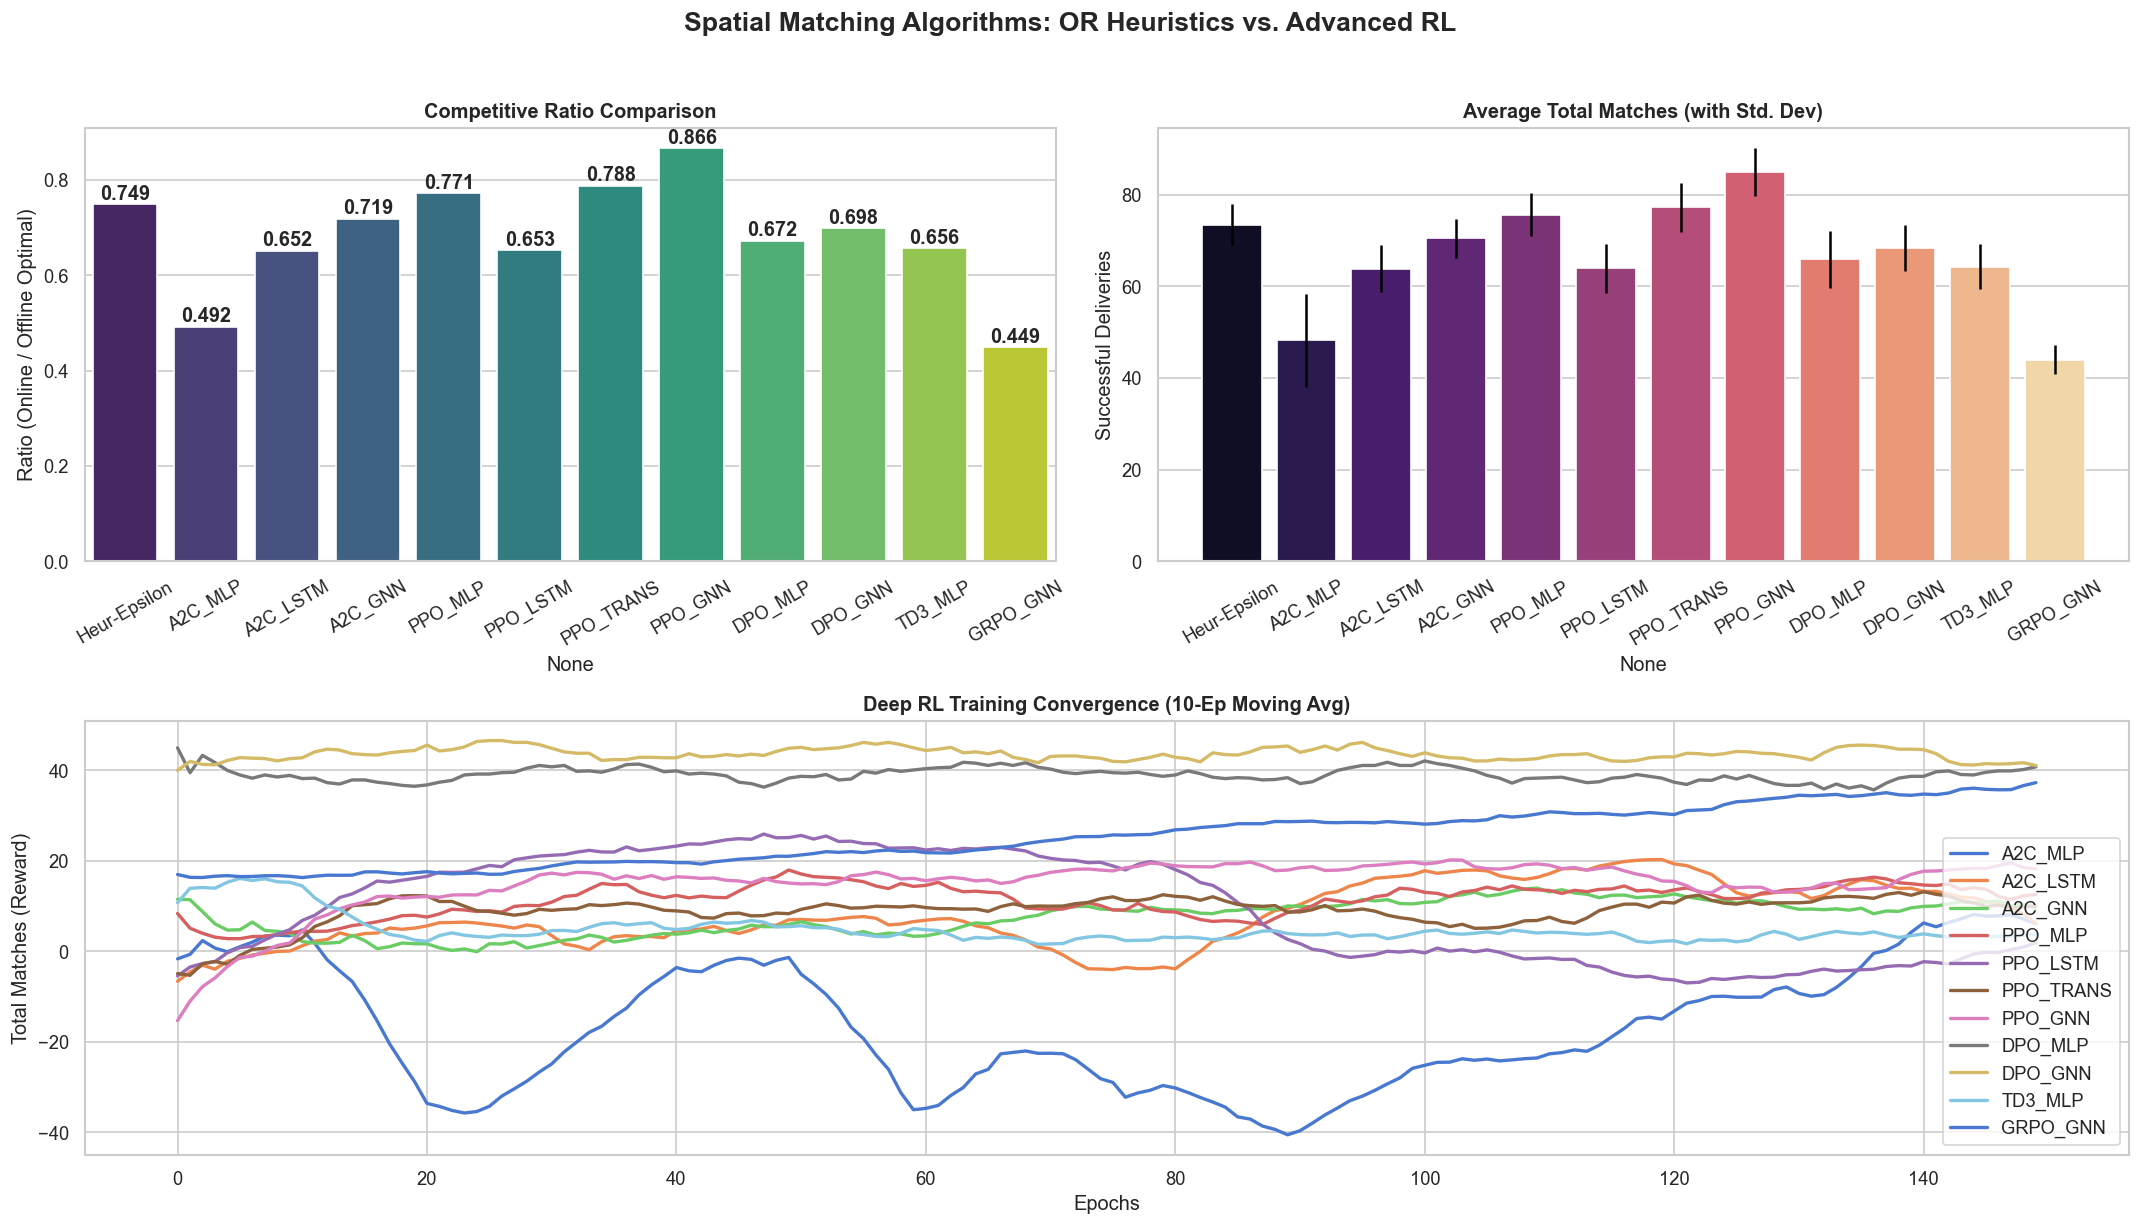


================== FINAL ANALYTICAL METRICS ==================


,Reward,Competitive_Ratio,Variance
PPO_GNN,84.850000,0.865816,5.217998
PPO_TRANS,77.200000,0.787755,5.427707
PPO_MLP,75.600000,0.771429,4.715930
Heur-Epsilon,73.450000,0.749490,4.510820
A2C_GNN,70.450000,0.718878,4.224630
DPO_GNN,68.450000,0.698469,5.024689
DPO_MLP,65.900000,0.672449,6.244197
TD3_MLP,64.300000,0.656122,4.879549
PPO_LSTM,63.950000,0.652551,5.342986
A2C_LSTM,63.850000,0.651531,5.131033


In [ ]:
# %% [code]
# Assemble results for evaluation
trained_models = {
    "Heur-Epsilon": EpsilonRankingAlgorithm(env.n_I), # Add heuristics for baseline
    "A2C_MLP": agent_a2c_mlp,
    "A2C_LSTM": agent_a2c_lstm,
    "A2C_GNN": agent_a2c_gnn,
    "PPO_MLP": agent_ppo_mlp,
    "PPO_LSTM": agent_ppo_lstm,
    "PPO_TRANS": agent_ppo_trans,
    "PPO_GNN": agent_ppo_gnn,
    "DPO_MLP": agent_dpo_mlp,
    "DPO_GNN": agent_dpo_gnn,
    "TD3_MLP": agent_td3_mlp,
    "GRPO_GNN": agent_grpo_gnn,
}

# Add any trained histories to the plot dictionary
all_histories = {
    "A2C_MLP": hist_a2c_mlp,
    "A2C_LSTM": hist_a2c_lstm,
    "A2C_GNN": hist_a2c_gnn,
    "PPO_MLP": hist_ppo_mlp,
    "PPO_LSTM": hist_ppo_lstm,
    "PPO_TRANS": hist_ppo_trans,
    "PPO_GNN": hist_ppo_gnn,
    "DPO_MLP": hist_dpo_mlp,
    "DPO_GNN": hist_dpo_gnn,
    "TD3_MLP": hist_td3_mlp,
    "GRPO_GNN": hist_grpo_gnn,
}

results = {}
test_orders = generate_arrival_orders(env.G, n_orders=20)

for name, agent in trained_models.items():
    rewards = []
    for order in test_orders:
        env.reset(order)
        reward = agent.run_episode(env)
        rewards.append(reward)
    
    results[name] = {
        'Reward': np.mean(rewards),
        'Competitive_Ratio': np.mean(rewards) / env.compute_offline_optimal(),
        'Variance': np.std(rewards)
    }
results_df = pd.DataFrame(results).T
generate_comparative_report(results_df, all_histories)